# EDA of application train dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
app_train=pd.read_csv('/Users/rageshwer/Goal ML/Projects/Home_Credit_Default_Risk/data/raw/application_train.csv')

## 1. Initial data inspection and creating column and summary dictionary.

In [2]:
print(f"The no of duplicate rows :{app_train.duplicated().sum()}")
app_train.head()

The no of duplicate rows :0


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Dictionary for columns type
col_app_train={
    'int64':[],
    'float64':[],
    'str':[]
}
for col in app_train.columns:
    col_app_train[str(app_train[col].dtype)].append(col)
for key,val in col_app_train.items():
    n=len(val)
    print(f"Total columns of {key} data type : {n}")
    i=0
    while(i+5<=n-1):
        print(val[i:i+5])
        i+=5
    print("_________________________________________________________________________________________________________")

Total columns of int64 data type : 41
['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'DAYS_BIRTH', 'DAYS_EMPLOYED']
['DAYS_ID_PUBLISH', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE']
['FLAG_PHONE', 'FLAG_EMAIL', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START']
['REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY']
['LIVE_CITY_NOT_WORK_CITY', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5']
['FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10']
['FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15']
['FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20']
_________________________________________________________________________________________________________
Total columns of float64 data type 

## 2. Missing, default rate and target variale distribution

In [4]:
# Summary for missing and unique data
summary_app_train=pd.DataFrame({
    'missing':app_train.isna().sum(),
    'missing %':round(app_train.isna().sum()*100/app_train.shape[0],ndigits=2),
    'unique':app_train.nunique()
})
summary_app_train

,missing,missing %,unique
SK_ID_CURR,0,0.0,307511
TARGET,0,0.0,2
NAME_CONTRACT_TYPE,0,0.0,2
CODE_GENDER,0,0.0,3
FLAG_OWN_CAR,0,0.0,2
...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,41519,13.5,9
AMT_REQ_CREDIT_BUREAU_WEEK,41519,13.5,9
AMT_REQ_CREDIT_BUREAU_MON,41519,13.5,24
AMT_REQ_CREDIT_BUREAU_QRT,41519,13.5,11


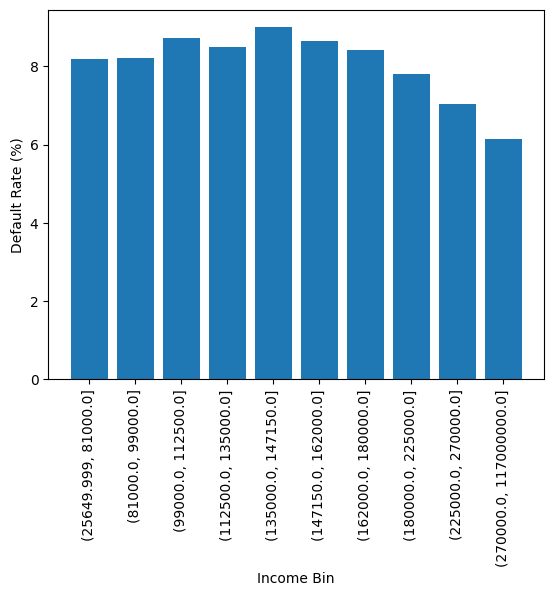

In [65]:
# Default rate by income class
default_app_train= app_train.groupby(
    pd.qcut(app_train['AMT_INCOME_TOTAL'],q=10)
)['TARGET'].mean()*100

plt.bar(x=range(len(default_app_train)),height=default_app_train.values)
plt.xticks(ticks=range(len(default_app_train)),labels=default_app_train.index,rotation=90)

plt.ylabel('Default Rate (%)')
plt.xlabel('Income Bin')
plt.show()

In [5]:
# Target class distribution analysis
app_train['TARGET'].value_counts(normalize=True)*100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

The target class is imbalanced. The accuracy score will be useless. The more important metric would be ROC AUC and recall.

## 3. Checking feature distribution and correlation

For checking the distribution of features, we are selecting only those features which seem relevant to a loan repayment capacity.

In [28]:
# Selecting important numerical columns that have direct relation with loan repayment capacity
important_num_cols = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'DAYS_REGISTRATION',
    'DAYS_ID_PUBLISH',
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3'
]

For plotting, to see the distribution, skewness and possible variation

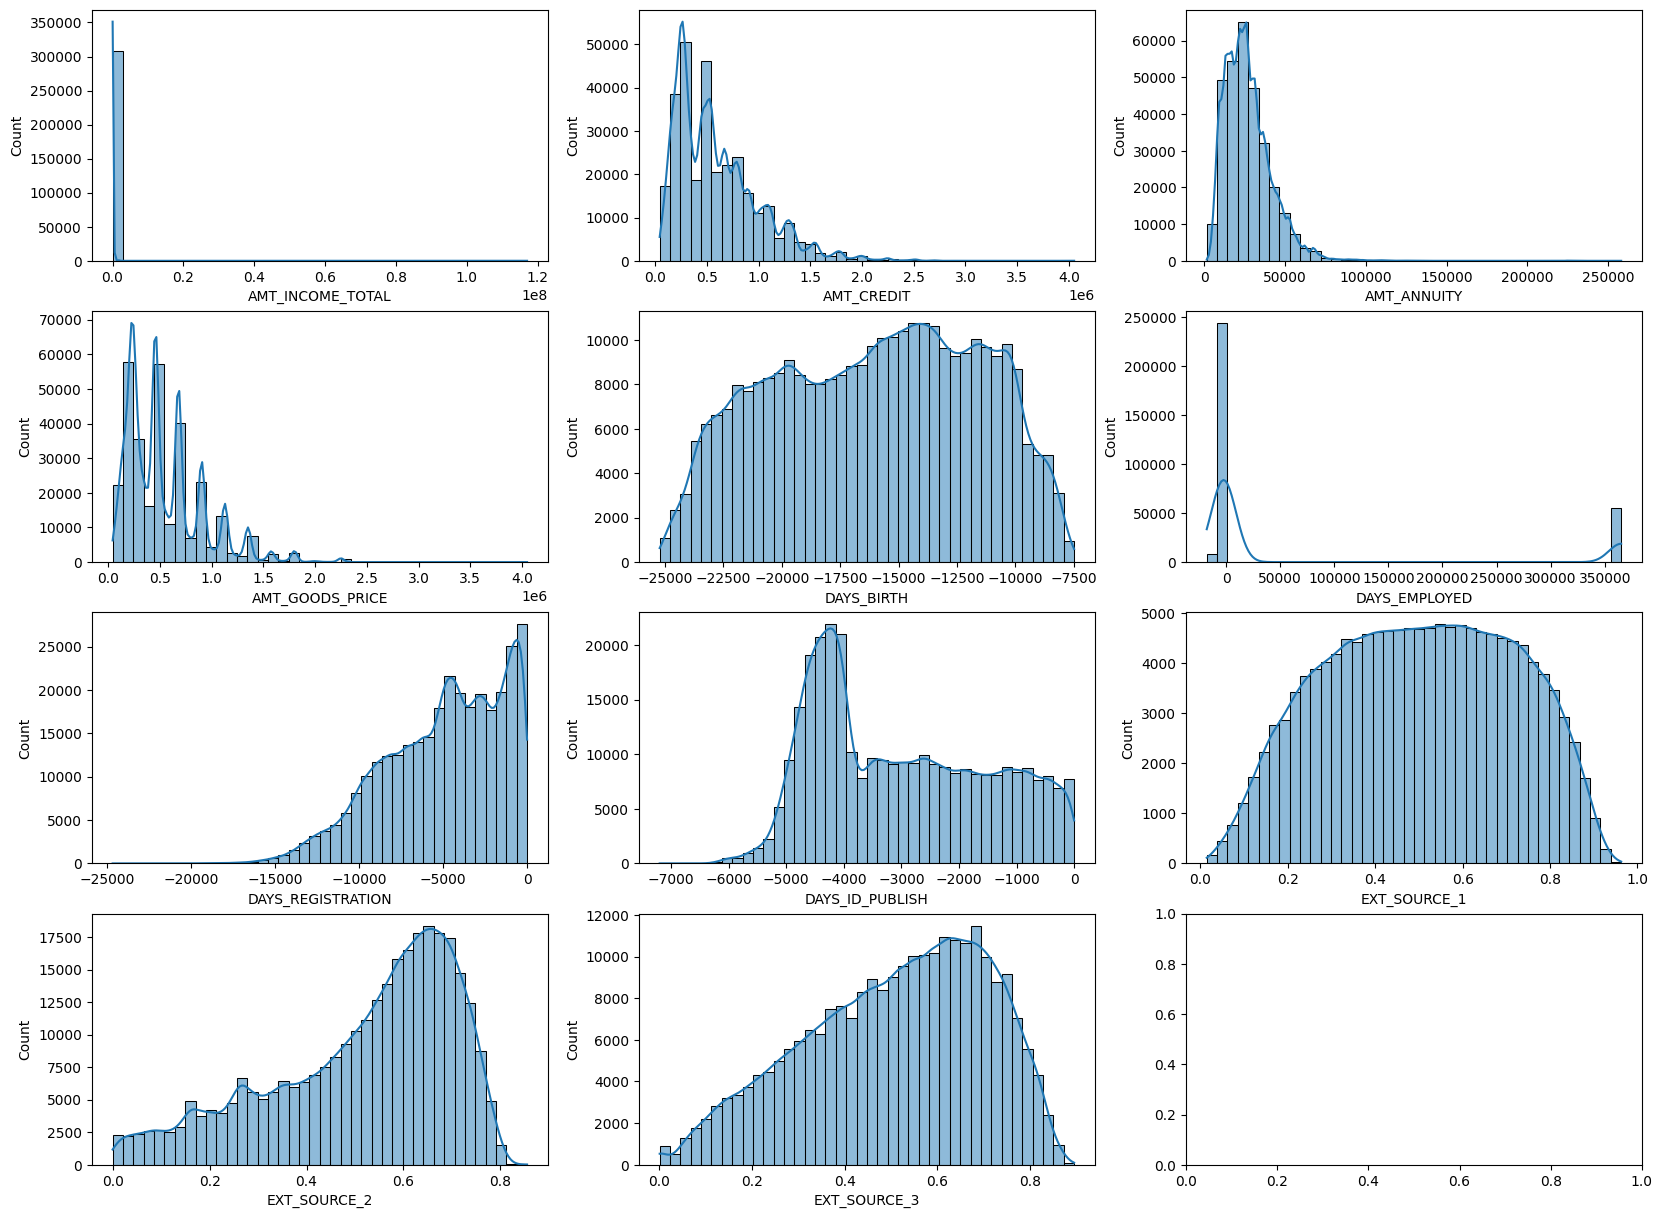

In [33]:
fig,axes=plt.subplots(4,3,figsize=(20,15))
n=0
for i in range(4):
    for j in range(3):
        if i==3 and j==2 : break
        sns.histplot(app_train[important_num_cols[n]],ax=axes[i,j],bins=40,kde=True)
        n+=1

The days employed column is showing abruptly large no of days for some portion of the data set.

In [77]:
app_train['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [78]:
sum(app_train['DAYS_EMPLOYED']==365243)

55374

Correlation of these features with the target variable.

<Axes: >

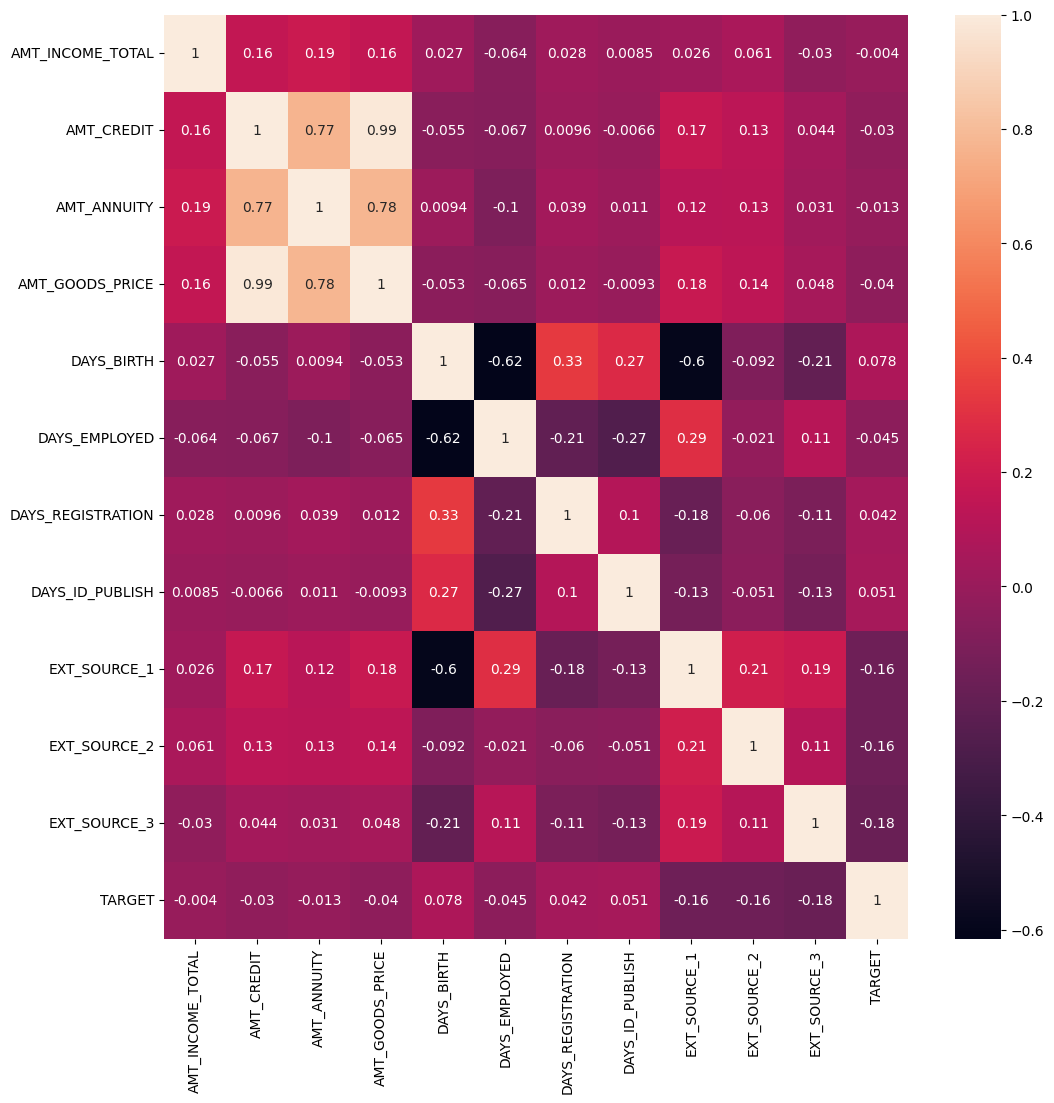

In [39]:
plt.figure(figsize=(12,12))
sns.heatmap(app_train[important_num_cols+['TARGET']].corr(),annot=True)

# 4. Exploring other features
The 'int' type has most binary features and 'float' has building related features.

In [ ]:
for col in col_app_train['int64']:
    print(f"Unique in {col} : {app_train[col].nunique()}")

Unique in SK_ID_CURR : 307511
Unique in TARGET : 2
Unique in CNT_CHILDREN : 15
Unique in DAYS_BIRTH : 17460
Unique in DAYS_EMPLOYED : 12574
Unique in DAYS_ID_PUBLISH : 6168
Unique in FLAG_MOBIL : 2
Unique in FLAG_EMP_PHONE : 2
Unique in FLAG_WORK_PHONE : 2
Unique in FLAG_CONT_MOBILE : 2
Unique in FLAG_PHONE : 2
Unique in FLAG_EMAIL : 2
Unique in REGION_RATING_CLIENT : 3
Unique in REGION_RATING_CLIENT_W_CITY : 3
Unique in HOUR_APPR_PROCESS_START : 24
Unique in REG_REGION_NOT_LIVE_REGION : 2
Unique in REG_REGION_NOT_WORK_REGION : 2
Unique in LIVE_REGION_NOT_WORK_REGION : 2
Unique in REG_CITY_NOT_LIVE_CITY : 2
Unique in REG_CITY_NOT_WORK_CITY : 2
Unique in LIVE_CITY_NOT_WORK_CITY : 2
Unique in FLAG_DOCUMENT_2 : 2
Unique in FLAG_DOCUMENT_3 : 2
Unique in FLAG_DOCUMENT_4 : 2
Unique in FLAG_DOCUMENT_5 : 2
Unique in FLAG_DOCUMENT_6 : 2
Unique in FLAG_DOCUMENT_7 : 2
Unique in FLAG_DOCUMENT_8 : 2
Unique in FLAG_DOCUMENT_9 : 2
Unique in FLAG_DOCUMENT_10 : 2
Unique in FLAG_DOCUMENT_11 : 2
Unique i

In [ ]:
# Checking the 15 different values in children column
app_train['CNT_CHILDREN'].unique()

array([ 0,  1,  2,  3,  4,  7,  5,  6,  8,  9, 11, 12, 10, 19, 14])

In [79]:
for col in col_app_train['float64']:
    print(f"Unique in {col} : {app_train[col].nunique()}")

Unique in AMT_INCOME_TOTAL : 2548
Unique in AMT_CREDIT : 5603
Unique in AMT_ANNUITY : 13672
Unique in AMT_GOODS_PRICE : 1002
Unique in REGION_POPULATION_RELATIVE : 81
Unique in DAYS_REGISTRATION : 15688
Unique in OWN_CAR_AGE : 62
Unique in CNT_FAM_MEMBERS : 17
Unique in EXT_SOURCE_1 : 114584
Unique in EXT_SOURCE_2 : 119831
Unique in EXT_SOURCE_3 : 814
Unique in APARTMENTS_AVG : 2339
Unique in BASEMENTAREA_AVG : 3780
Unique in YEARS_BEGINEXPLUATATION_AVG : 285
Unique in YEARS_BUILD_AVG : 149
Unique in COMMONAREA_AVG : 3181
Unique in ELEVATORS_AVG : 257
Unique in ENTRANCES_AVG : 285
Unique in FLOORSMAX_AVG : 403
Unique in FLOORSMIN_AVG : 305
Unique in LANDAREA_AVG : 3527
Unique in LIVINGAPARTMENTS_AVG : 1868
Unique in LIVINGAREA_AVG : 5199
Unique in NONLIVINGAPARTMENTS_AVG : 386
Unique in NONLIVINGAREA_AVG : 3290
Unique in APARTMENTS_MODE : 760
Unique in BASEMENTAREA_MODE : 3841
Unique in YEARS_BEGINEXPLUATATION_MODE : 221
Unique in YEARS_BUILD_MODE : 154
Unique in COMMONAREA_MODE : 3128

In [ ]:
# Categorical features
for col in col_app_train['str']:
    print(f"Unique in {col} : {app_train[col].nunique()}")

Unique in NAME_CONTRACT_TYPE : 2
Unique in CODE_GENDER : 3
Unique in FLAG_OWN_CAR : 2
Unique in FLAG_OWN_REALTY : 2
Unique in NAME_TYPE_SUITE : 7
Unique in NAME_INCOME_TYPE : 8
Unique in NAME_EDUCATION_TYPE : 5
Unique in NAME_FAMILY_STATUS : 6
Unique in NAME_HOUSING_TYPE : 6
Unique in OCCUPATION_TYPE : 18
Unique in WEEKDAY_APPR_PROCESS_START : 7
Unique in ORGANIZATION_TYPE : 58
Unique in FONDKAPREMONT_MODE : 4
Unique in HOUSETYPE_MODE : 3
Unique in WALLSMATERIAL_MODE : 7
Unique in EMERGENCYSTATE_MODE : 2


In [83]:
print(app_train['ORGANIZATION_TYPE'].unique())
print(app_train['OCCUPATION_TYPE'].unique())

<ArrowStringArray>
['Business Entity Type 3',                 'School',             'Government',
               'Religion',                  'Other',                    'XNA',
            'Electricity',               'Medicine', 'Business Entity Type 2',
          'Self-employed',      'Transport: type 2',           'Construction',
                'Housing',           'Kindergarten',          'Trade: type 7',
      'Industry: type 11',               'Military',               'Services',
    'Security Ministries',      'Transport: type 4',       'Industry: type 1',
              'Emergency',               'Security',          'Trade: type 2',
             'University',      'Transport: type 3',                 'Police',
 'Business Entity Type 1',                 'Postal',       'Industry: type 4',
            'Agriculture',             'Restaurant',                'Culture',
                  'Hotel',       'Industry: type 7',          'Trade: type 3',
       'Industry: type 3',       

In [86]:
app_train.groupby('OCCUPATION_TYPE')["TARGET"].mean()*100

OCCUPATION_TYPE
Accountants               4.830327
Cleaning staff            9.606705
Cooking staff            10.443996
Core staff                6.303954
Drivers                  11.326130
HR staff                  6.394316
High skill tech staff     6.159930
IT staff                  6.463878
Laborers                 10.578770
Low-skill Laborers       17.152413
Managers                  6.214028
Medicine staff            6.700246
Private service staff     6.598793
Realty agents             7.856192
Sales staff               9.631799
Secretaries               7.049808
Security staff           10.742449
Waiters/barmen staff     11.275964
Name: TARGET, dtype: float64

In [87]:
app_train.groupby('ORGANIZATION_TYPE')["TARGET"].mean()*100

ORGANIZATION_TYPE
Advertising                8.158508
Agriculture               10.472698
Bank                       5.185481
Business Entity Type 1     8.138369
Business Entity Type 2     8.528381
Business Entity Type 3     9.299623
Cleaning                  11.153846
Construction              11.679810
Culture                    5.540897
Electricity                6.631579
Emergency                  7.142857
Government                 6.978085
Hotel                      6.418219
Housing                    7.944557
Industry: type 1          11.068335
Industry: type 10          6.422018
Industry: type 11          8.653846
Industry: type 12          3.794038
Industry: type 13         13.432836
Industry: type 2           7.205240
Industry: type 3          10.616229
Industry: type 4          10.148233
Industry: type 5           6.844741
Industry: type 6           7.142857
Industry: type 7           8.033665
Industry: type 8          12.500000
Industry: type 9           6.680523
Insurance 

In [90]:
for col in ['NAME_INCOME_TYPE','NAME_EDUCATION_TYPE','NAME_FAMILY_STATUS','NAME_HOUSING_TYPE']:
    print("___________________________________")
    print(
        app_train.groupby(col)['TARGET']
        .mean()
        .sort_values(ascending=False)
        * 100
    )

___________________________________
NAME_INCOME_TYPE
Maternity leave         40.000000
Unemployed              36.363636
Working                  9.588472
Commercial associate     7.484257
State servant            5.754965
Pensioner                5.386366
Businessman              0.000000
Student                  0.000000
Name: TARGET, dtype: float64
___________________________________
NAME_EDUCATION_TYPE
Lower secondary                  10.927673
Secondary / secondary special     8.939929
Incomplete higher                 8.484966
Higher education                  5.355115
Academic degree                   1.829268
Name: TARGET, dtype: float64
___________________________________
NAME_FAMILY_STATUS
Civil marriage          9.944584
Single / not married    9.807675
Separated               8.194234
Married                 7.559868
Widow                   5.824217
Unknown                 0.000000
Name: TARGET, dtype: float64
___________________________________
NAME_HOUSING_TYPE
Rented apa

# Observations:
1. There are large no of features that pertain to the house/building/flat of the borrower. This shows the socio economic status of the borrower. We might not need all of these features but will need better feature importance testing.
2. The repayment ability of the borrower is the main reason for a loan default. These important features include income, loan amount, existing debt. Some other important features might also include borrower age and type of employment.
3. The bureau features in the application dataset only include the no of enquires. This is an important feature, as it describes how many places the borrower is trying to get a loan and not getting approved.
4. EXT_SOURCE 2 and 3 are moderately left skewed, meaning large population received favourable scores.
5. AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY, and AMT_GOODS_PRICE exhibit strong positive skewness. Most applicants are concentrated in lower monetary ranges, while a relatively small number of customers have very large incomes or loan exposures. Outlier investigation may be required during feature engineering.
6. The 'DAYS EMPLOYED' column has 365243 for 55k borrowers. This comes out to be 1000 years. This is definitely something that we will further dive into FE.
7. The correlation matrix showed that age has negative 0.6 correlation with EXT_SOURCE 1. This source is giving importance to age as a factor in scoring. The rest correlations of annuity, credit, goods price are expected as the values will depend on each other. The target variable is not showing any strong correlation with any of individual features. This suggests that there might be non linear correlation that can arise from interactions.
8. The children column have 15 unique values, the borrower with more members and low total income may default.
9. Low skill labourers have 17 % default rate which is more than double the default rate of whole dataset. And transport type 3 have 15.7% default rate.
10. The maternity leave as income type has 40% default rate, and unemployed coming with 36%. Further investigation is required to see if the sample size is stong enough to make such hypotheses true.
